In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from scipy.stats import gaussian_kde, ks_2samp
import os
import kagglehub
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

from yellowbrick.cluster import KElbowVisualizer
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /Users/katiegalaeva/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


В рамках данного исследования использовался датасет, содержащий информацию по признакам age, bmi и charges. Данные предварительно были нормализованы для устранения влияния различий в масштабах признаков. Целью анализа было выявление кластеров в данных.

**Для кластеризации был выбран алгоритм K-means.**


- Предобработка данных:
   Нормализация признаков с использованием StandardScaler, чтобы все переменные имели сопоставимые масштабы.

- Выбор числа кластеров:
    Для определения оптимального количества кластеров использовались метод локтя и коэффициент силуэта. Визуальный анализ показал, что при разбиении на 3–4 кластера данные начинают стабильно группироваться.

- Кластеризация:
    После выбора оптимального числа кластеров алгоритм K-means был применен к нормализованным данным.

**K-means был выбран по следующим причинам**

- Структура данных:
    Данные по признакам age, bmi и charges демонстрируют достаточно компактные группы, которые хорошо описываются центроидами. Визуализация показала, что кластеры имеют относительно сферическую/эллиптическую форму, что соответствует предположениям алгоритма K-means.

- Стабильность и интерпретируемость:
    В отличие от методов, чувствительных к выбросам (например, DBSCAN), K-means всегда распределяет все точки по заданному числу кластеров, что упрощает интерпретацию. Центроиды кластеров легко интерпретировать как представителя каждого сегмента (например, средние значения возраста, bmi и расходов в кластере).


**Сравнение с другими методами:**

- DBSCAN:
    При применении DBSCAN наблюдалось, что алгоритм объединяет большинство точек в один кластер при подобранных параметрах что усложняет анализ. Это связано с тем, что данные не содержат резких перепадов плотности, необходимых для эффективной работы DBSCAN. Данный метод не продемонстрирован в этом ноутбуке, так как данный подход не принес никаких результатов.




In [54]:
csv_file = os.path.join(path, "insurance.csv")

df_original = pd.read_csv(csv_file)
df_original.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [55]:
df_original

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


В качестве признаков возьмем 'age', 'bmi', 'charges'

In [109]:
from sklearn.preprocessing import StandardScaler

features = ['age', 'bmi', 'charges']
df = df_original.copy()
scaler = StandardScaler()
df[features] = scaler.fit_transform(df_original[features])

X_norm = df[features].values


/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_74469/4047056070.py:7: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_74469/4047056070.py:7: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_74469/4

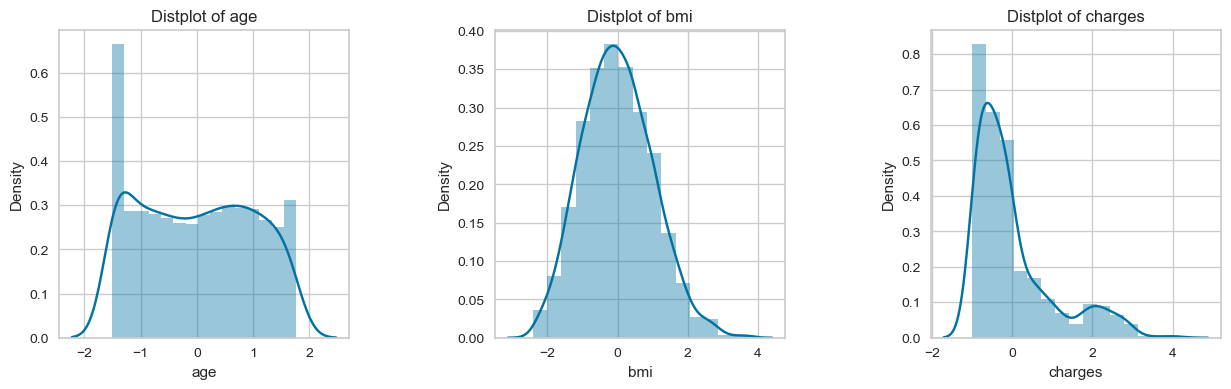

In [57]:
plt.figure(1 , figsize = (15 , 4))
n = 0 
for x in ['age' , 'bmi' , 'charges']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 15)
    plt.title('Distplot of {}'.format(x))
plt.show()

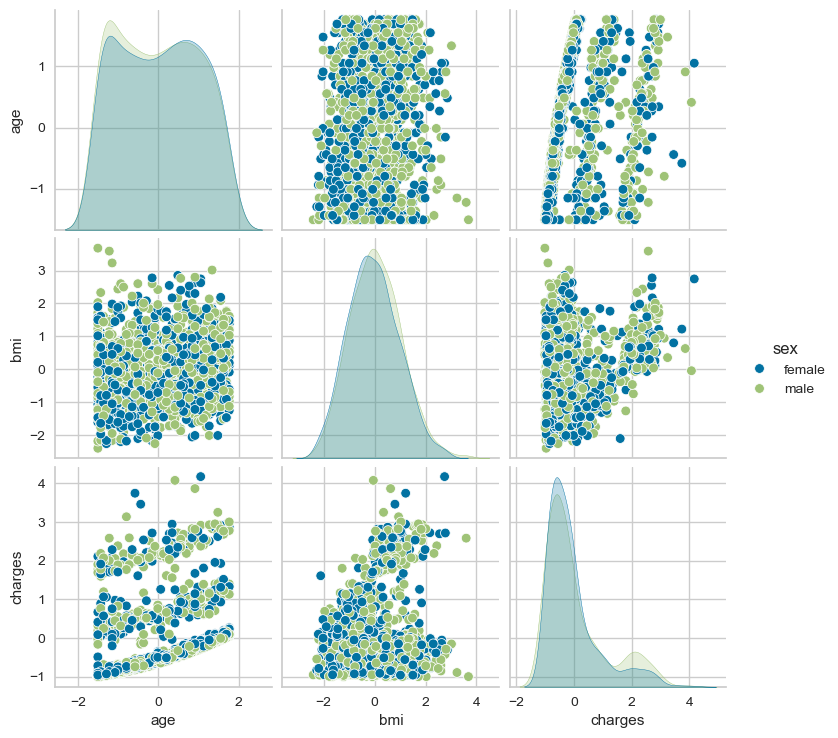

In [58]:
sns.pairplot(df, vars = ['age' , 'bmi' , 'charges'], hue = "sex")

Применим для класстеризации KMeans

DBSCAN на данных показался не совсем уместным и при использовании его выделялся только один большой класстер при найденных параметрах. 

In [59]:
kmeans_params = {
    'init': 'k-means++',
    'n_init': 10,
    'max_iter': 300, 
    'tol': 0.0001,
    'random_state': 42,
    'algorithm': 'elkan'
}

Рассмотрим данные Age vs charges

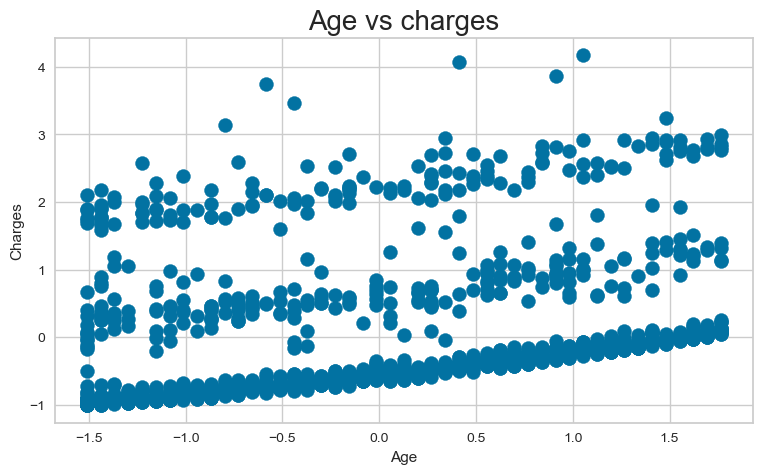

In [111]:
plt.figure(1 , figsize = (9 , 5))
plt.title('Age vs charges', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.scatter( x = 'age', y = 'charges', data = df, s = 100)
plt.show()

In [61]:
X1 = df[['age' , 'charges']].iloc[: , :].values
inertia = []
for n in range(1 , 15):
    algorithm = KMeans(n_clusters = n, **kmeans_params)
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

/Users/katiegalaeva/miniconda3/envs/env_01/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:1408: RuntimeWarning:

algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.



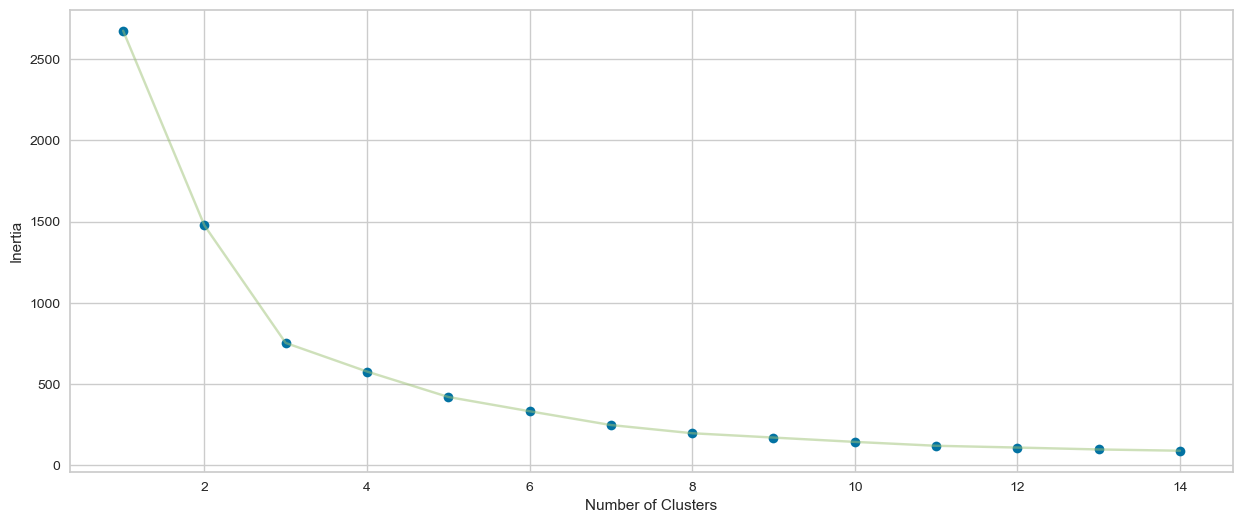

In [62]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

Методом локтя можно заметить, что оптимальным значением является значение около 4

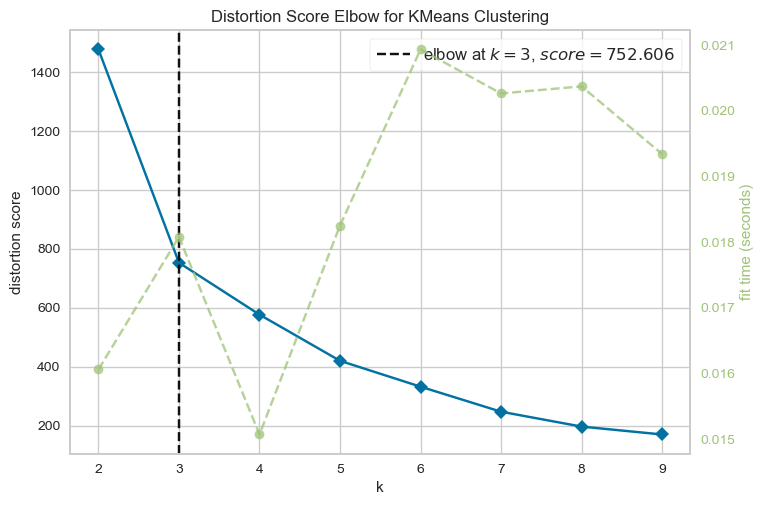

In [63]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10))

visualizer.fit(X1)
visualizer.show()
plt.show()

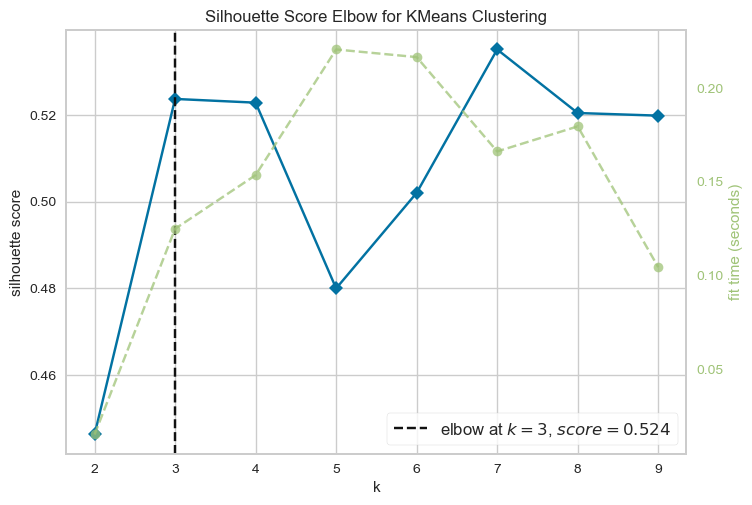

In [64]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette')

visualizer.fit(X1)
visualizer.show()
plt.show()

Оптимальным является значение 3

Построим класстеризацию со значением 3

In [87]:
N_CLUSTERS = 3

In [88]:
algorithm = KMeans(n_clusters = N_CLUSTERS, **kmeans_params)
algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

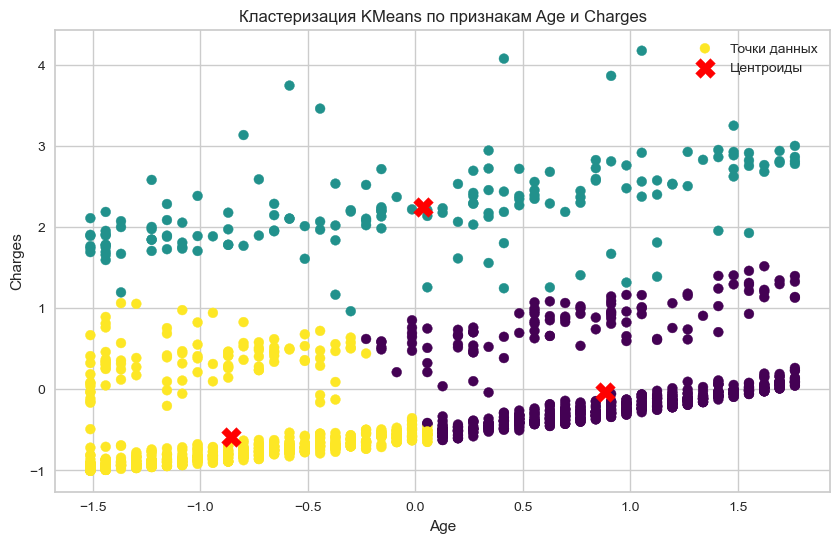

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.scatter(X1[:, 0], X1[:, 1], c=labels1, s=50, cmap='viridis', label='Точки данных')

plt.scatter(centroids1[:, 0], centroids1[:, 1], c='red', s=200, marker='X', label='Центроиды')

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Кластеризация KMeans по признакам Age и Charges")
plt.legend()
plt.show()


Визуально кластеризация выглядит осмысленно: KMeans разбил выборку на три группы по сочетанию возраста и стоимости страховки. 

Сделаем класстеризацию для 'bmi' , 'charges'

In [90]:
X2 = df[['bmi' , 'charges']].iloc[: , :].values
inertia = []
for n in range(1 , 15):
    algorithm = KMeans(n_clusters = n, **kmeans_params)
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

/Users/katiegalaeva/miniconda3/envs/env_01/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:1408: RuntimeWarning:

algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.



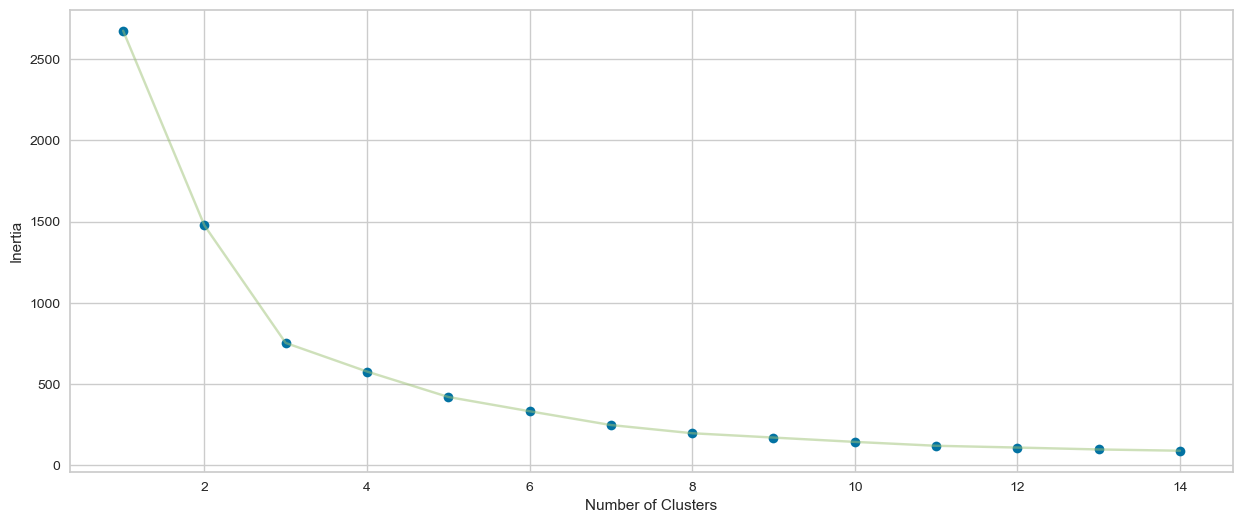

In [91]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

Методом локтя оптимальное значение 4

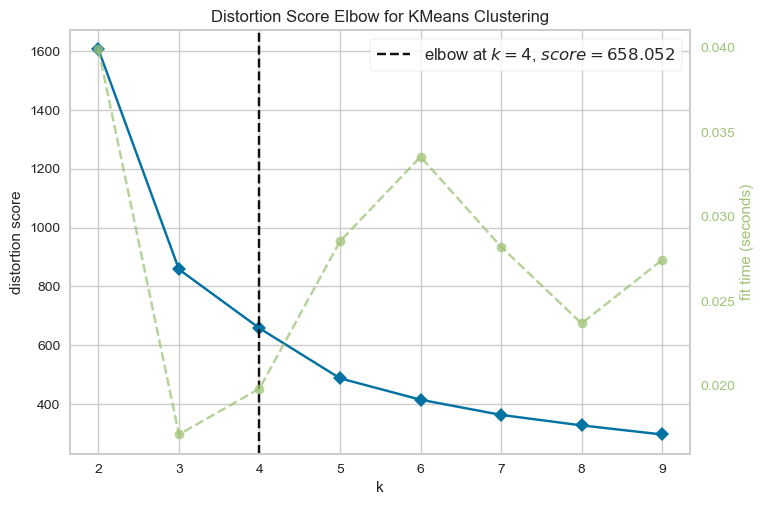

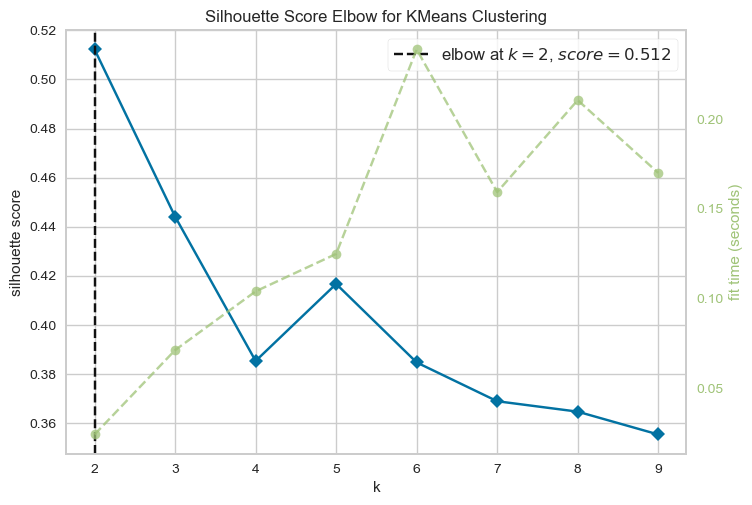

In [92]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10))

visualizer.fit(X2)
visualizer.show()
plt.show()
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette')

visualizer.fit(X2)
visualizer.show()
plt.show()

Итого оптимальное значение 4

Построим график как будут распределенны точки по класстерам

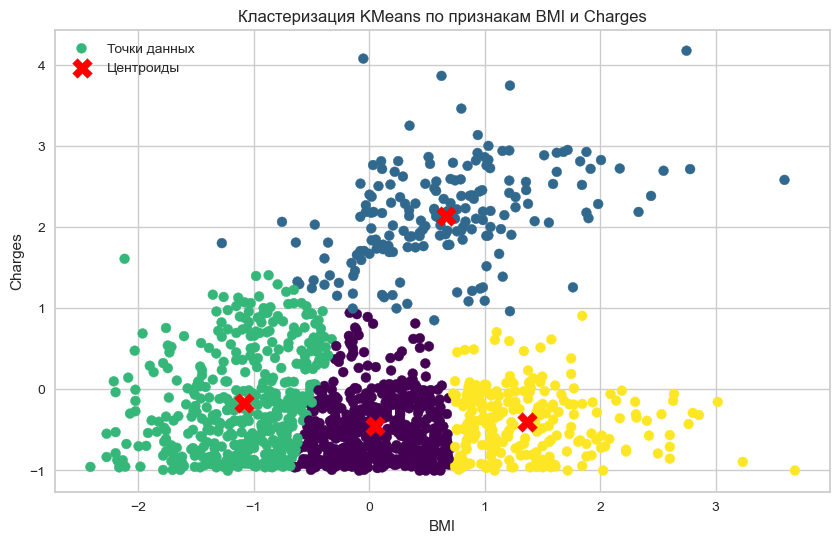

In [ ]:
N_CLUSTERS = 4
algorithm = KMeans(n_clusters = N_CLUSTERS, **kmeans_params)
algorithm.fit(X2)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1], c=labels1, s=50, cmap='viridis', label='Точки данных')
plt.scatter(centroids1[:, 0], centroids1[:, 1], c='red', s=200, marker='X', label='Центроиды')

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Кластеризация KMeans по признакам BMI и Charges")
plt.legend()
plt.show()


Кластеризация по признакам BMI и Charges выявила четыре относительно обособленные группы. 

Попробуем сделать класстеризацию для трех признаков 'age', 'bmi', 'charges'

In [94]:
X3 = df[['age', 'bmi', 'charges']].iloc[: , :].values
inertia = []
for n in range(1 , 11):
    algorithm = KMeans(n_clusters = n, **kmeans_params)
    algorithm.fit(X3)
    inertia.append(algorithm.inertia_)

/Users/katiegalaeva/miniconda3/envs/env_01/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:1408: RuntimeWarning:

algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.



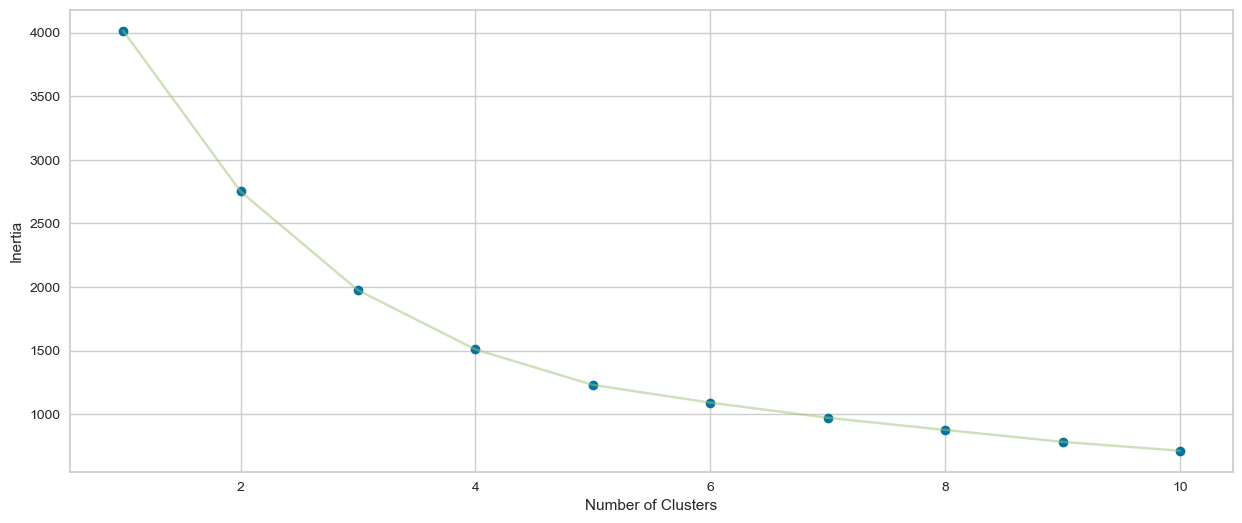

In [95]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

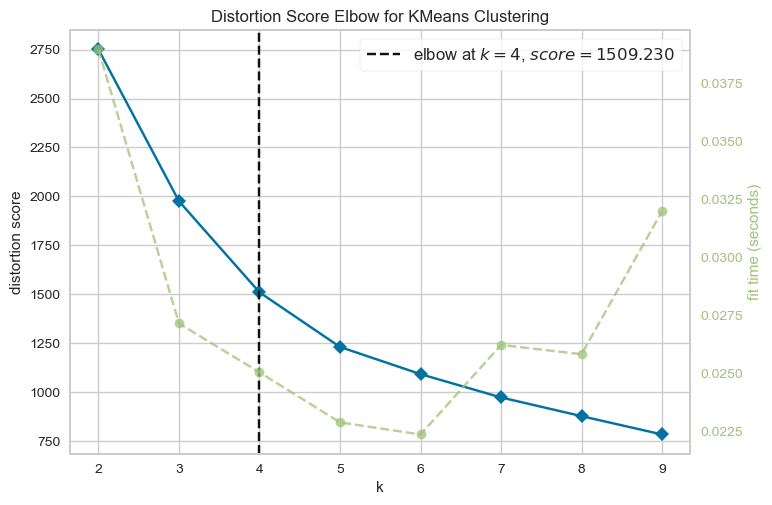

In [96]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10))

visualizer.fit(X3)
visualizer.show()
plt.show()

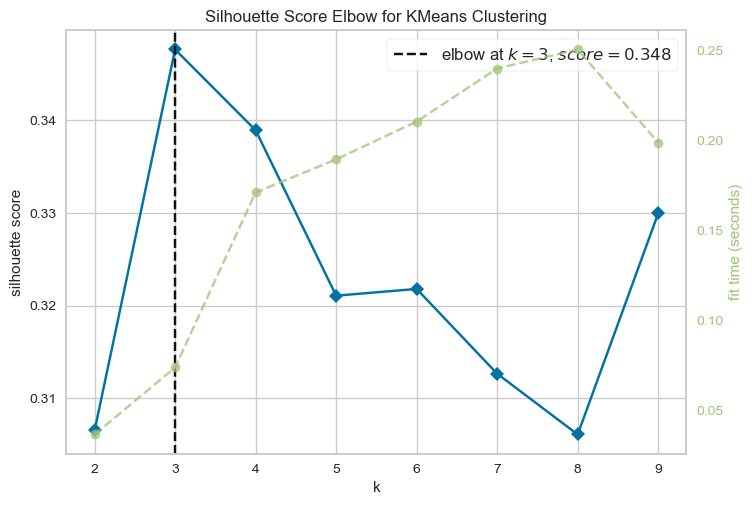

In [97]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette')

visualizer.fit(X3)
visualizer.show()
plt.show()

Оптимально значение 3 - 4

In [98]:
N_CLUSTERS = 3
algorithm = KMeans(n_clusters = N_CLUSTERS, **kmeans_params)
algorithm.fit(X3)
labels3 = algorithm.labels_
centroids3 = algorithm.cluster_centers_

y_kmeans = algorithm.fit_predict(X3)
df['cluster_kmeans'] = y_kmeans
df.groupby('cluster_kmeans').size()

cluster_kmeans
0    572
1    605
2    161
dtype: int64

In [99]:
import plotly as py
import plotly.graph_objs as go
def plot_3d(colname):
    trace1 = go.Scatter3d(
        x= df['age'],
        y= df['bmi'],
        z= df['charges'],
        mode='markers',
        marker=dict(
            color = df[colname], 
            size= 10,
            line=dict(
                color= df[colname],
                width= 12
            ),
            opacity=0.8
        )
    )
    data = [trace1]
    layout = go.Layout(
        title= 'Clusters with Age, BMI and Charges',
        scene = dict(
                xaxis = dict(title  = 'age'),
                yaxis = dict(title  = 'bmi'),
                zaxis = dict(title  = 'charges')
            )
    )
    fig = go.Figure(data=data, layout=layout)
    py.offline.iplot(fig)

In [100]:
plot_3d('cluster_kmeans')

In [112]:
N_CLUSTERS = 4
algorithm = KMeans(n_clusters = N_CLUSTERS, **kmeans_params)
algorithm.fit(X3)
labels3 = algorithm.labels_
centroids3 = algorithm.cluster_centers_

y_kmeans = algorithm.fit_predict(X3)
df['cluster_kmeans'] = y_kmeans
df.groupby('cluster_kmeans').size()

cluster_kmeans
0    389
1    294
2    164
3    491
dtype: int64

In [113]:
import plotly as py
import plotly.graph_objs as go
def plot_3d(colname):
    trace1 = go.Scatter3d(
        x= df['age'],
        y= df['bmi'],
        z= df['charges'],
        mode='markers',
        marker=dict(
            color = df[colname], 
            size= 10,
            line=dict(
                color= df[colname],
                width= 12
            ),
            opacity=0.8
        )
    )
    data = [trace1]
    layout = go.Layout(
        title= 'Clusters with Age, BMI and Charges',
        scene = dict(
                xaxis = dict(title  = 'age'),
                yaxis = dict(title  = 'bmi'),
                zaxis = dict(title  = 'charges')
            )
    )
    fig = go.Figure(data=data, layout=layout)
    py.offline.iplot(fig)

In [114]:
plot_3d('cluster_kmeans')

По методу локтя и по методу силуета были найдены значения 3 и 4. Думаю, здесь дальше нужно отталкиваться уже от бизнес задачи. Если требуется более детальная сегментация и каждый кластер можно практически интерпретировать, то K=4 может быть уместнее. Если важна простота и достаточен крупный грубый разрез, можно взять K=3

**Выводы**

Анализ данных показал, что их структура хорошо соответствует предположениям K-means. Отсутствие явных выбросов и разнородной плотности делает алгоритм DBSCAN менее эффективным для данного набора данных. Визуализация и количественные метрики (например, коэффициент силуэта) подтверждают, что кластеризация с помощью K-means обеспечивает стабильное и интерпретируемое разделение на сегменты.

Выделенные кластеры позволяют сегментировать клиентов по возрасту, состоянию здоровья (BMI) и стоимости страховки (charges), что может быть использовано в дальнейшем при построении модели.

